# 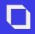 IONCOR Oy UKI Scrap Value Forecasting Dashboard (Random Forest Regressor,XGBoost, ARIMA, LSTM, Prophet)

## 📦 Import, Load libraries and packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")


## 📁 Uploaded Files and Setup

In [2]:
files = {
    "ZELLBLOCK_RE_Uki": "Desktop/Thesis_project/Thesis_Test_ML/ZELLBLOCK_RE_Uki.XLSX",
    "ZELLBLOCK_LI_Uki": "Desktop/Thesis_project/Thesis_Test_ML/ZELLBLOCK_LI_Uki.XLSX",
    "LI_ION_Cell_Uki": "Desktop/Thesis_project/Thesis_Test_ML/LI_ION_Cell_Uki.XLSX",
    "Prismatic_Cell_Uki": "Desktop/Thesis_project/Thesis_Test_ML/Prismatic_Cell_Uki.XLSX"
}


## ⚙️ Define Files and Preprocessing Function

In [3]:
def preprocess_time_series(file_path):
    df = pd.read_excel(file_path)
    df = df[['Posting Date', 'Amount in LC']]
    df = df.groupby('Posting Date').sum().reset_index()
    df = df.sort_values('Posting Date')
    df = df.dropna()
    return df

## 🧠 XGBoost Prediction

In [4]:
def xgboost_model(df):
    df['Year'] = df['Posting Date'].dt.year
    df['Month'] = df['Posting Date'].dt.month
    df['Day'] = df['Posting Date'].dt.day

    X = df[['Year', 'Month', 'Day']]
    y = df['Amount in LC']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    model = XGBRegressor(n_estimators=200, learning_rate=0.1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    return rmse, y_test.reset_index(drop=True), y_pred

## 🔁 ARIMA Forecasting

In [5]:
from statsmodels.tsa.arima.model import ARIMA

def arima_model(df):
    series = df.set_index('Posting Date')['Amount in LC']
    model = ARIMA(series, order=(5,1,0))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=int(len(series) * 0.2))
    y_true = series[-len(forecast):]
    rmse = mean_squared_error(y_true, forecast, squared=False)
    return rmse, y_true, forecast

## 🔮 Prophet Forecasting

In [6]:
from prophet import Prophet

def prophet_model(df):
    df = df.rename(columns={'Posting Date': 'ds', 'Amount in LC': 'y'})
    model = Prophet()
    model.fit(df)
    future = model.make_future_dataframe(periods=int(len(df) * 0.2))
    forecast = model.predict(future)
    y_pred = forecast[['ds', 'yhat']].tail(int(len(df) * 0.2))
    y_true = df['y'].tail(int(len(df) * 0.2)).reset_index(drop=True)
    rmse = mean_squared_error(y_true, y_pred['yhat'], squared=False)
    return rmse, y_true, y_pred['yhat']

## 🤖 LSTM Forecasting

In [7]:
from keras.models import Sequential
from keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
def lstm_model(df):
    df = df.set_index('Posting Date')
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[['Amount in LC']])

    generator = TimeseriesGenerator(scaled, scaled, length=10, batch_size=1)
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=(10,1)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    model.fit(generator, epochs=10, verbose=0)

    # Forecast
    predictions = []
    batch = scaled[-10:].reshape((1, 10, 1))
    for _ in range(int(len(df) * 0.2)):
        pred = model.predict(batch, verbose=0)
        predictions.append(pred[0][0])
        batch = np.append(batch[:,1:,:], [pred], axis=1).reshape(1, -1, 1)

    predictions = scaler.inverse_transform(np.array(predictions).reshape(-1,1)).flatten()
    y_true = df['Amount in LC'].tail(len(predictions))
    rmse = mean_squared_error(y_true, predictions, squared=False)
    return rmse, y_true.reset_index(drop=True), predictions

## 📊 Run All Models on Each Dataset

In [8]:
results = {}

for name, path in files.items():
    df = preprocess_time_series(path)
    res = {}
    res['XGBoost'] = xgboost_model(df)
    res['ARIMA'] = arima_model(df)
    res['Prophet'] = prophet_model(df)
    res['LSTM'] = lstm_model(df)
    results[name] = res
    print(f"{name} - Completed")


C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given wit

ZELLBLOCK_RE_Uki - Completed


C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given wit

ZELLBLOCK_LI_Uki - Completed


C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given wit

LI_ION_Cell_Uki - Completed


C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given wit

Prismatic_Cell_Uki - Completed


## 📉 Compare RMSEs

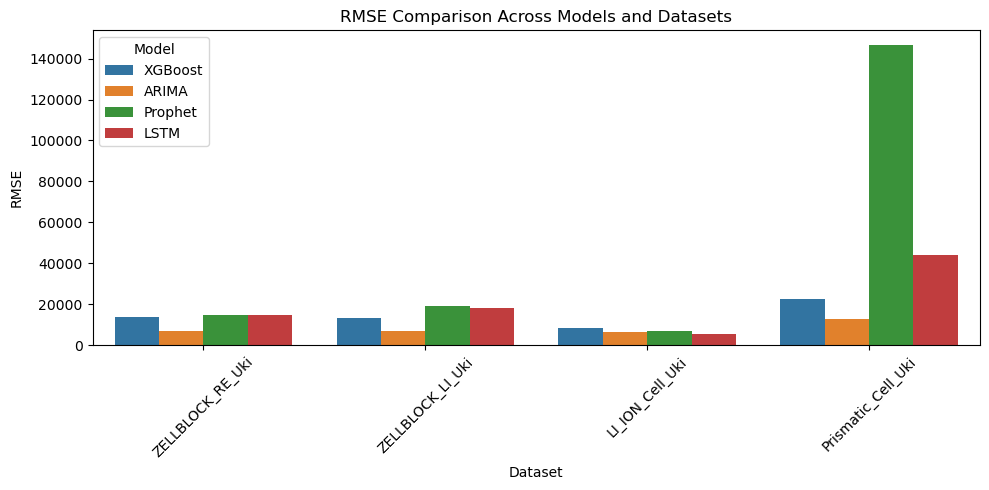

In [9]:
rmse_df = pd.DataFrame([
    {'Dataset': dataset, 'Model': model, 'RMSE': results[dataset][model][0]}
    for dataset in results for model in results[dataset]
])

plt.figure(figsize=(10, 5))
sns.barplot(data=rmse_df, x='Dataset', y='RMSE', hue='Model')
plt.title('RMSE Comparison Across Models and Datasets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ⏳ Data preprocessing

In [10]:
# Selecting features and target variable
columns_of_interest = [
    'Posting Date', 'Amount in LC'
]
data_subset = df[columns_of_interest].dropna()


In [11]:
# Encode categorical features (Material, Movement Type)
data_subset['Posting Date'] = data_subset['Posting Date'].astype('category').cat.codes

In [12]:
# Split data into features (X) and target (y)
X = data_subset[['Posting Date']]
y = data_subset['Amount in LC']


## 🔮 Forecast/Prediction

In [13]:
# Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 🤖 Model Inference

In [14]:
# Train a Random Forest Regressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [15]:
# Predict on test data
y_pred = model.predict(X_test)

In [16]:
#Mean Absolute Error (MAE): Close to zero, suggesting very small prediction errors.
# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)
#R² Score: Zero, implying that the model isn't explaining variance in the target.
# Calculate R² Score
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R²) Score: {r2:.4f}")

Mean Absolute Error (MAE): 23291.8165
R-squared (R²) Score: 0.5269


In [17]:
# Inspecting the distribution of the target variable (Amount in LC)
y.describe(), y.value_counts()

(count        51.000000
 mean     -57444.538431
 std      131008.402941
 min     -830506.690000
 25%      -33723.165000
 50%      -21460.190000
 75%       -9727.960000
 max       -3058.080000
 Name: Amount in LC, dtype: float64,
 Amount in LC
 -3065.74      6
 -21460.19     3
 -18394.44     3
 -25049.20     2
 -309720.07    1
 -36788.91     1
 -30657.41     1
 -24525.94     1
 -24525.93     1
 -45986.16     1
 -12262.96     1
 -33723.16     1
 -30657.44     1
 -12262.98     1
 -27591.69     1
 -21460.18     1
 -6131.48      1
 -6131.49      1
 -42920.42     1
 -32916.41     1
 -33723.17     1
 -9197.22      1
 -371003.34    1
 -70667.45     1
 -63992.76     1
 -191887.56    1
 -21288.06     1
 -10644.27     1
 -49641.02     1
 -152337.06    1
 -830506.69    1
 -7066.74      1
 -24525.92     1
 -105619.85    1
 -14082.65     1
 -10258.70     1
 -31300.50     1
 -9173.58      1
 -9174.24      1
 -3058.08      1
 -24203.24     1
 Name: count, dtype: int64)

## 📊 📈 Chart and Trend Pridiction

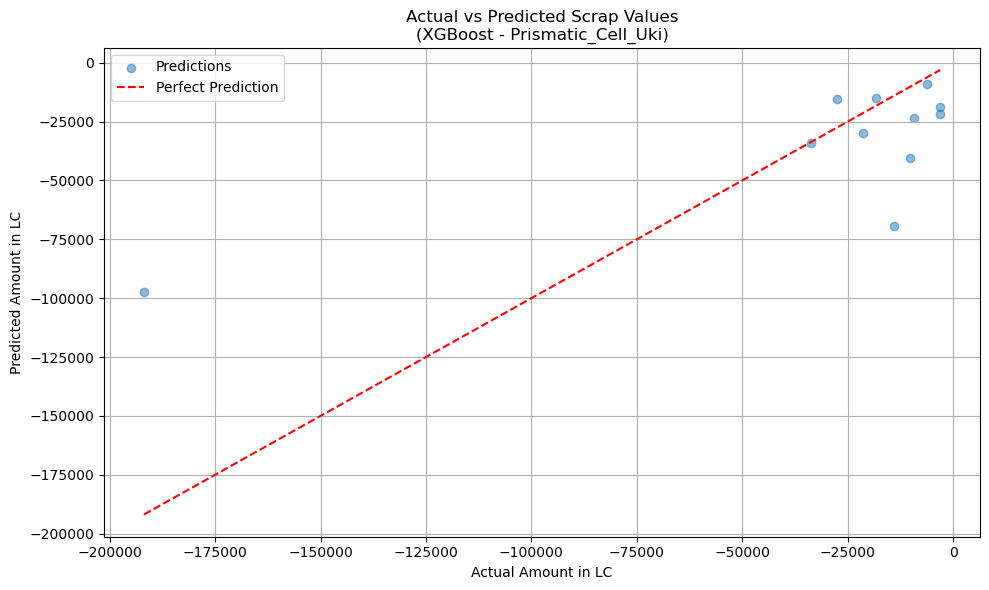

In [18]:
# After model training in your train_and_evaluate_model function:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label='Predictions')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 
         'r--', label='Perfect Prediction')
plt.title(f"Actual vs Predicted Scrap Values\n(XGBoost - {name})", fontsize=12)
plt.xlabel("Actual Amount in LC", fontsize=10)
plt.ylabel("Predicted Amount in LC", fontsize=10)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

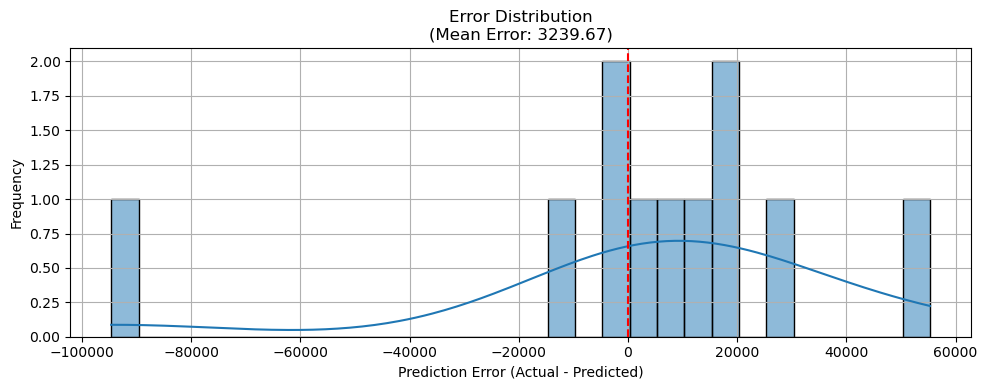

In [19]:
# After predictions are generated:
errors = y_test - y_pred

plt.figure(figsize=(10, 4))
sns.histplot(errors, kde=True, bins=30)
plt.axvline(x=0, color='r', linestyle='--')
plt.title(f"Error Distribution\n(Mean Error: {np.mean(errors):.2f})", fontsize=12)
plt.xlabel("Prediction Error (Actual - Predicted)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()